In [2]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.ticker as mticker

In [3]:
path = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/cumulative_09_24/weekly_patterns_START-2024-09-02.csv"
WeeklyPatterns = pd.read_csv(path)
WeeklyPatterns.drop_duplicates(inplace=True)
WeeklyPatterns.head()

,placekey,parent_placekey,safegraph_brand_ids,location_name,brands,store_id,top_category,sub_category,naics_code,latitude,...,median_dwell,bucketed_dwell_times,related_same_day_brand,related_same_week_brand,device_type,normalized_visits_by_state_scaling,normalized_visits_by_region_naics_visits,normalized_visits_by_region_naics_visitors,normalized_visits_by_total_visits,normalized_visits_by_total_visitors
0,zzy-226@627-wdj-h3q,NaN,NaN,New York Cruises,NaN,NaN,Scenic and Sightseeing Transportation,NaN,487,40.583511,...,1.0,"{ ""<5"":356, ""5-20"":7, ""21-60"":8, ""61-240"":16, ...","{""Macy's Backstage"":54,""Dunkin'"":52,""Auntie An...","{""Dunkin'"":168,""Mobil"":114,""Starbucks"":110,""Au...","{""ios"":138,""android"":44}",5289.0,0.029913,0.039307,0.000082,0.000656
1,22c-222@5x4-4vx-5zz,NaN,NaN,West Seattle Recycling,NaN,NaN,Waste Management and Remediation Services,NaN,562,47.568590,...,11.0,"{ ""<5"":13, ""5-20"":1, ""21-60"":0, ""61-240"":0, "">...","{""BECU"":5,""Danner Boots"":4,""Earthbound Trading...","{""BECU"":8,""Starbucks"":8,""FedEx"":6,""Goodwill In...","{""android"":4}",220.0,0.011280,0.011939,0.000006,0.000096
2,226-227@8sz-v5r-y35,NaN,NaN,San Antonio Inpatient Drug Rehab,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,29.430125,...,15.0,"{ ""<5"":89, ""5-20"":6, ""21-60"":4, ""61-240"":6, "">...","{""Thompson Hotels"":20,""Jefferson Bank Texas"":1...","{""Chick-fil-A"":26,""FedEx"":24,""Bubba Gump Shrim...","{""ios"":40,""android"":9}",1613.0,0.004657,0.005115,0.000008,0.000096
3,223-222@5x4-6yt-6p9,NaN,NaN,The Firs,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.052627,...,17.0,"{ ""<5"":18, ""5-20"":4, ""21-60"":2, ""61-240"":1, "">...","{""Providence Health & Services"":4,""Famous Foot...","{""Providence Health & Services"":5,""Chevron"":4,...","{""android"":9,""ios"":4}",393.0,0.012874,0.014085,0.000012,0.000173
4,22c-222@5x4-4sg-3qz,22x-222@5x4-4sg-3qz,NaN,Assisted Living Concepts,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.459007,...,179.0,"{ ""<5"":48, ""5-20"":3, ""21-60"":3, ""61-240"":15, ""...","{""Embassy Suites Hotels"":18,""Ramada"":18,""WoodS...","{""Chevron"":18,""Embassy Suites Hotels"":18,""Rama...","{""android"":49,""ios"":6}",1010.0,0.033200,0.036609,0.000029,0.000442


In [4]:
path2 = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/cumulative_09_24/weekly_patterns_START-2024-09-09.csv"
WeeklyPatterns2 = pd.read_csv(path2)
WeeklyPatterns2.drop_duplicates(inplace=True)
WeeklyPatterns2.head()

,placekey,parent_placekey,safegraph_brand_ids,location_name,brands,store_id,top_category,sub_category,naics_code,latitude,...,median_dwell,bucketed_dwell_times,related_same_day_brand,related_same_week_brand,device_type,normalized_visits_by_state_scaling,normalized_visits_by_region_naics_visits,normalized_visits_by_region_naics_visitors,normalized_visits_by_total_visits,normalized_visits_by_total_visitors
0,234-222@5pj-5gd-psq,NaN,NaN,Traffic Legal Solutions,NaN,NaN,Transit and Ground Passenger Transportation,NaN,485,38.629607,...,164.0,"{ ""<5"":167, ""5-20"":7, ""21-60"":7, ""61-240"":15, ...","{""Cargill Manufacturing"":107,""Rotary Club"":35,...","{""Cargill Manufacturing"":124,""Starbucks"":56,""Q...","{""ios"":68,""android"":45}",3342.0,0.074626,0.082368,0.000075,0.000736
1,zzy-255@63r-v8g-7wk,zzw-222@63r-vj3-jjv,NaN,British Airways,NaN,NaN,Transit and Ground Passenger Transportation,NaN,485,38.952741,...,18.0,"{ ""<5"":2984, ""5-20"":2068, ""21-60"":1261, ""61-24...","{""Duty Free Americas"":2654,""Dunkin'"":1367,""Sta...","{""Duty Free Americas"":2743,""Dunkin'"":1972,""Sta...","{""ios"":1792,""android"":1485}",103971.0,0.378934,1.880346,0.002405,0.034177
2,222-229@5x4-6yt-6kz,NaN,NaN,VA Olympia Outpatiant Clinic,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.053685,...,33.0,"{ ""<5"":41, ""5-20"":20, ""21-60"":30, ""61-240"":1, ...","{""Providence Health & Services"":28,""McDonald's...","{""Providence Health & Services"":32,""Starbucks""...","{""android"":76,""ios"":4}",1521.0,0.051881,0.055904,0.000047,0.000679
3,222-22k@5pk-n7d-xwk,22c-222@5pk-n7d-xwk,NaN,St Louis Plumbing,NaN,NaN,Building Equipment Contractors,NaN,2382,38.701339,...,99.0,"{ ""<5"":271, ""5-20"":36, ""21-60"":59, ""61-240"":11...","{""Sheraton Hotels & Resorts"":185,""Farmers Insu...","{""Farmers Insurance Group"":194,""Sheraton Hotel...","{""ios"":217,""android"":124}",8326.0,0.070768,0.079770,0.000186,0.001813
4,222-224@5z4-ryp-9mk,NaN,NaN,Family Floors,NaN,NaN,Building Finishing Contractors,NaN,2383,33.716511,...,2.0,"{ ""<5"":46, ""5-20"":3, ""21-60"":3, ""61-240"":1, "">...","{""The UPS Store"":15,""Chevron Extra Mile"":11,""C...","{""The UPS Store"":20,""Chevron Extra Mile"":16,""C...","{""ios"":15,""android"":11}",699.0,0.002344,0.002785,0.000005,0.000097


In [5]:
path3 = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/cumulative_09_24/weekly_patterns_START-2024-09-16.csv"
WeeklyPatterns3 = pd.read_csv(path3)
WeeklyPatterns3.drop_duplicates(inplace=True)
WeeklyPatterns3.head()

,placekey,parent_placekey,safegraph_brand_ids,location_name,brands,store_id,top_category,sub_category,naics_code,latitude,...,median_dwell,bucketed_dwell_times,related_same_day_brand,related_same_week_brand,device_type,normalized_visits_by_state_scaling,normalized_visits_by_region_naics_visits,normalized_visits_by_region_naics_visitors,normalized_visits_by_total_visits,normalized_visits_by_total_visitors
0,229-222@5x4-4qp-k4v,NaN,NaN,Pleasant Adult Family Home,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.500157,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,222-222@5x2-zgz-w6k,NaN,NaN,Beacons of Hope AFH,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,48.741907,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2b3-222@5xc-jv6-gzf,222-227@5xc-jv6-gzf,NaN,The Integrated Feminine,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,45.523411,...,9.0,"{ ""<5"":30, ""5-20"":4, ""21-60"":2, ""61-240"":0, "">...","{""Amazon Distribution"":8,""Fred Meyer Jewelers""...","{""7-Eleven"":14,""Progressive"":12,""Providence He...","{""android"":14,""ios"":10}",497.0,0.024412,0.027572,0.000030,0.000496
3,222-223@8fc-8d5-gtv,NaN,NaN,UES Enrollment Center,NaN,NaN,Social Assistance,NaN,624,29.749944,...,51.0,"{ ""<5"":98, ""5-20"":8, ""21-60"":6, ""61-240"":6, "">...","{""Exxon Mobil"":16,""McDonald's"":14,""Shell Oil"":...","{""Exxon Mobil"":51,""McDonald's"":50,""Shell Oil"":...","{""android"":63,""ios"":18}",1814.0,0.167729,0.168059,0.000008,0.000112
4,22w-223@5pw-69q-gkz,NaN,NaN,Chapman's Heating & Cooling,NaN,NaN,Building Equipment Contractors,NaN,2382,41.884123,...,1.0,"{ ""<5"":28, ""5-20"":0, ""21-60"":0, ""61-240"":0, "">...","{""Starbucks"":10,""Allbirds"":9,""Billy Reid"":9,""M...","{""Starbucks"":18,""Dunkin'"":17,""7-Eleven"":16,""Ch...","{""ios"":15,""android"":4}",417.0,0.000987,0.001276,0.000004,0.000065


In [6]:
path4 = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/cumulative_09_24/weekly_patterns_START-2024-09-23.csv"
WeeklyPatterns4 = pd.read_csv(path4)
WeeklyPatterns4.drop_duplicates(inplace=True)
WeeklyPatterns4.head()

,placekey,parent_placekey,safegraph_brand_ids,location_name,brands,store_id,top_category,sub_category,naics_code,latitude,...,median_dwell,bucketed_dwell_times,related_same_day_brand,related_same_week_brand,device_type,normalized_visits_by_state_scaling,normalized_visits_by_region_naics_visits,normalized_visits_by_region_naics_visitors,normalized_visits_by_total_visits,normalized_visits_by_total_visitors
0,223-252@8g7-4pm-yd9,zzw-224@8g7-4pm-wzf,NaN,WestJet,NaN,NaN,Transit and Ground Passenger Transportation,NaN,485,33.640820,...,18.0,"{ ""<5"":12999, ""5-20"":10077, ""21-60"":7805, ""61-...","{""InMotion"":14851,""McDonald's"":14480,""Asian Ch...","{""McDonald's"":16169,""InMotion"":15651,""L'Occita...","{""ios"":9323,""android"":6231}",408404.0,0.513454,3.254458,0.004945,0.053695
1,222-222@3x5-6nd-pjv,NaN,NaN,Spokane Septic Tank Pumping,NaN,NaN,Waste Management and Remediation Services,NaN,562,47.662508,...,108.0,"{ ""<5"":34, ""5-20"":3, ""21-60"":2, ""61-240"":7, "">...","{""Courtyard by Marriott"":7,""Ben & Jerry's"":5,""...","{""Starbucks"":13,""Courtyard by Marriott"":10,""Su...","{""android"":13,""ios"":4}",605.0,0.038785,0.040846,0.000019,0.000315
2,zzw-222@5x4-4b5-kmk,zzw-227@5x4-4b5-n3q,NaN,Drug Rehab and Sober Living Seattle,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.613279,...,1.0,"{ ""<5"":73, ""5-20"":4, ""21-60"":3, ""61-240"":5, "">...","{""American Job Centers"":52,""Impark"":39,""Starbu...","{""Starbucks"":61,""Impark"":54,""WeWork"":53,""Ameri...","{""ios"":49,""android"":18}",1012.0,0.039662,0.042910,0.000032,0.000538
3,222-22c@5xc-k48-52k,NaN,NaN,Apollo Plumbing Heating & Air Conditioning,NaN,NaN,Building Equipment Contractors,NaN,2382,45.661739,...,208.0,"{ ""<5"":24, ""5-20"":6, ""21-60"":12, ""61-240"":18, ...","{""Dutch Bros Coffee"":18,""Panda Express"":18,""AR...","{""Panda Express"":30,""Dutch Bros Coffee"":24,""Fr...","{""android"":18,""ios"":6}",925.0,0.021033,0.025139,0.000030,0.000495
4,zzy-222@5qv-wyn-hdv,NaN,NaN,SPI Asphalt Paving & Maintenance,NaN,NaN,Building Finishing Contractors,NaN,2383,33.030464,...,1.0,"{ ""<5"":713, ""5-20"":2, ""21-60"":4, ""61-240"":16, ...","{""QuikTrip"":142,""Exxon Mobil"":117,""Starbucks"":...","{""Exxon Mobil"":298,""QuikTrip"":290,""Walmart Pha...","{""ios"":360,""android"":12}",8375.0,0.009670,0.012715,0.000042,0.000615


In [7]:
path5 = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/cumulative_09_24/weekly_patterns_START-2024-09-30.csv"
WeeklyPatterns5 = pd.read_csv(path5)
WeeklyPatterns5.drop_duplicates(inplace=True)
WeeklyPatterns5.head()

,placekey,parent_placekey,safegraph_brand_ids,location_name,brands,store_id,top_category,sub_category,naics_code,latitude,...,median_dwell,bucketed_dwell_times,related_same_day_brand,related_same_week_brand,device_type,normalized_visits_by_state_scaling,normalized_visits_by_region_naics_visits,normalized_visits_by_region_naics_visitors,normalized_visits_by_total_visits,normalized_visits_by_total_visitors
0,224-222@5x4-86s-d5f,NaN,NaN,V Van Dyke,NaN,NaN,Transit and Ground Passenger Transportation,NaN,485,47.253225,...,121.0,"{ ""<5"":15, ""5-20"":0, ""21-60"":0, ""61-240"":4, "">...","{""24 Hour Fitness"":6,""Planet Fitness"":6,""Amazo...","{""Amazon Distribution"":8,""Chevron"":8,""24 Hour ...","{""android"":4,""ios"":4}",259.0,0.007876,0.008411,0.000008,0.000114
1,223-225@5wc-38q-snq,NaN,NaN,Ars Transport Brocerage,NaN,NaN,Transit and Ground Passenger Transportation,NaN,485,46.574759,...,140.0,"{ ""<5"":20, ""5-20"":1, ""21-60"":0, ""61-240"":1, "">...","{""Best Western"":7,""Chevron"":6,""Jackson Hewitt ...","{""Best Western"":9,""76"":6,""Barnes and Noble Col...","{""android"":9}",366.0,0.010947,0.011765,0.000011,0.000163
2,229-222@3x5-3g9-zs5,NaN,NaN,Shared Transitions,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.693236,...,33.0,"{ ""<5"":4, ""5-20"":0, ""21-60"":4, ""61-240"":0, "">2...","{""Airrosti"":4,""Great Clips"":4,""H&R Block"":4,""H...","{""H&R Block"":9,""Airrosti"":4,""Allstate Insuranc...","{""ios"":5}",118.0,0.003722,0.004078,0.000004,0.000051
3,zzw-222@5x4-49z-vmk,NaN,NaN,Comfort At Home Homecare,NaN,NaN,Nursing and Residential Care Facilities,NaN,623,47.654313,...,1.0,"{ ""<5"":53, ""5-20"":0, ""21-60"":0, ""61-240"":0, "">...","{""Crate and Barrel"":7,""MOD Pizza"":5,""FedEx"":4,...","{""Starbucks"":22,""Chase"":19,""Crate and Barrel"":...","{""android"":29,""ios"":17}",720.0,0.024614,0.026705,0.000023,0.000327
4,222-222@5x4-6ys-n89,NaN,NaN,Capital Heating Cooling & Plumbing,NaN,NaN,Building Equipment Contractors,NaN,2382,47.034879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
week_labels = ["2024-09-02", "2024-09-09", "2024-09-16", "2024-09-23", "2024-09-30"]
dfs = [WeeklyPatterns, WeeklyPatterns2, WeeklyPatterns3, WeeklyPatterns4, WeeklyPatterns5]

for df, week in zip(dfs, week_labels):
    df['week_start'] = week

WeeklyPatterns_combined = pd.concat(dfs, ignore_index=True)
WeeklyPatterns_combined.drop_duplicates(inplace=True)
WeeklyPatterns_combined = WeeklyPatterns_combined[WeeklyPatterns_combined['region'] == 'VA']


In [9]:
# poi_cbg is a 12-digit FIPS: 2 state + 3 county + 6 tract + 1 block group
WeeklyPatterns_combined['county'] = WeeklyPatterns_combined['poi_cbg'].str[2:5]
WeeklyPatterns_combined['census_tract'] = WeeklyPatterns_combined['poi_cbg'].str[5:11]
WeeklyPatterns_combined['naics2'] = WeeklyPatterns_combined['naics_code'].astype(str).str[:2]

In [21]:
#print(WeeklyPatterns_combined.shape)
print(WeeklyPatterns_combined['poi_cbg'])

208        511079801001
1171       511079801001
1722       510594206001
2133       510594802022
2227       510594605011
               ...     
2132964    511079801001
2133041    517700003003
2133203    510594822034
2133207    511079801001
2133479    510853208011
Name: poi_cbg, Length: 8186, dtype: object


In [32]:
print(WeeklyPatterns_combined.columns)

Index(['placekey', 'parent_placekey', 'safegraph_brand_ids', 'location_name',
       'brands', 'store_id', 'top_category', 'sub_category', 'naics_code',
       'latitude', 'longitude', 'street_address', 'city', 'region',
       'postal_code', 'open_hours', 'category_tags', 'opened_on', 'closed_on',
       'tracking_closed_since', 'websites', 'geometry_type', 'polygon_wkt',
       'polygon_class', 'enclosed', 'phone_number', 'is_synthetic',
       'includes_parking_lot', 'iso_country_code', 'wkt_area_sq_meters',
       'date_range_start', 'date_range_end', 'raw_visit_counts',
       'raw_visitor_counts', 'visits_by_day', 'visits_by_each_hour', 'poi_cbg',
       'visitor_home_cbgs', 'visitor_home_aggregation', 'visitor_daytime_cbgs',
       'visitor_country_of_origin', 'distance_from_home', 'median_dwell',
       'bucketed_dwell_times', 'related_same_day_brand',
       'related_same_week_brand', 'device_type',
       'normalized_visits_by_state_scaling',
       'normalized_visits_by_regi

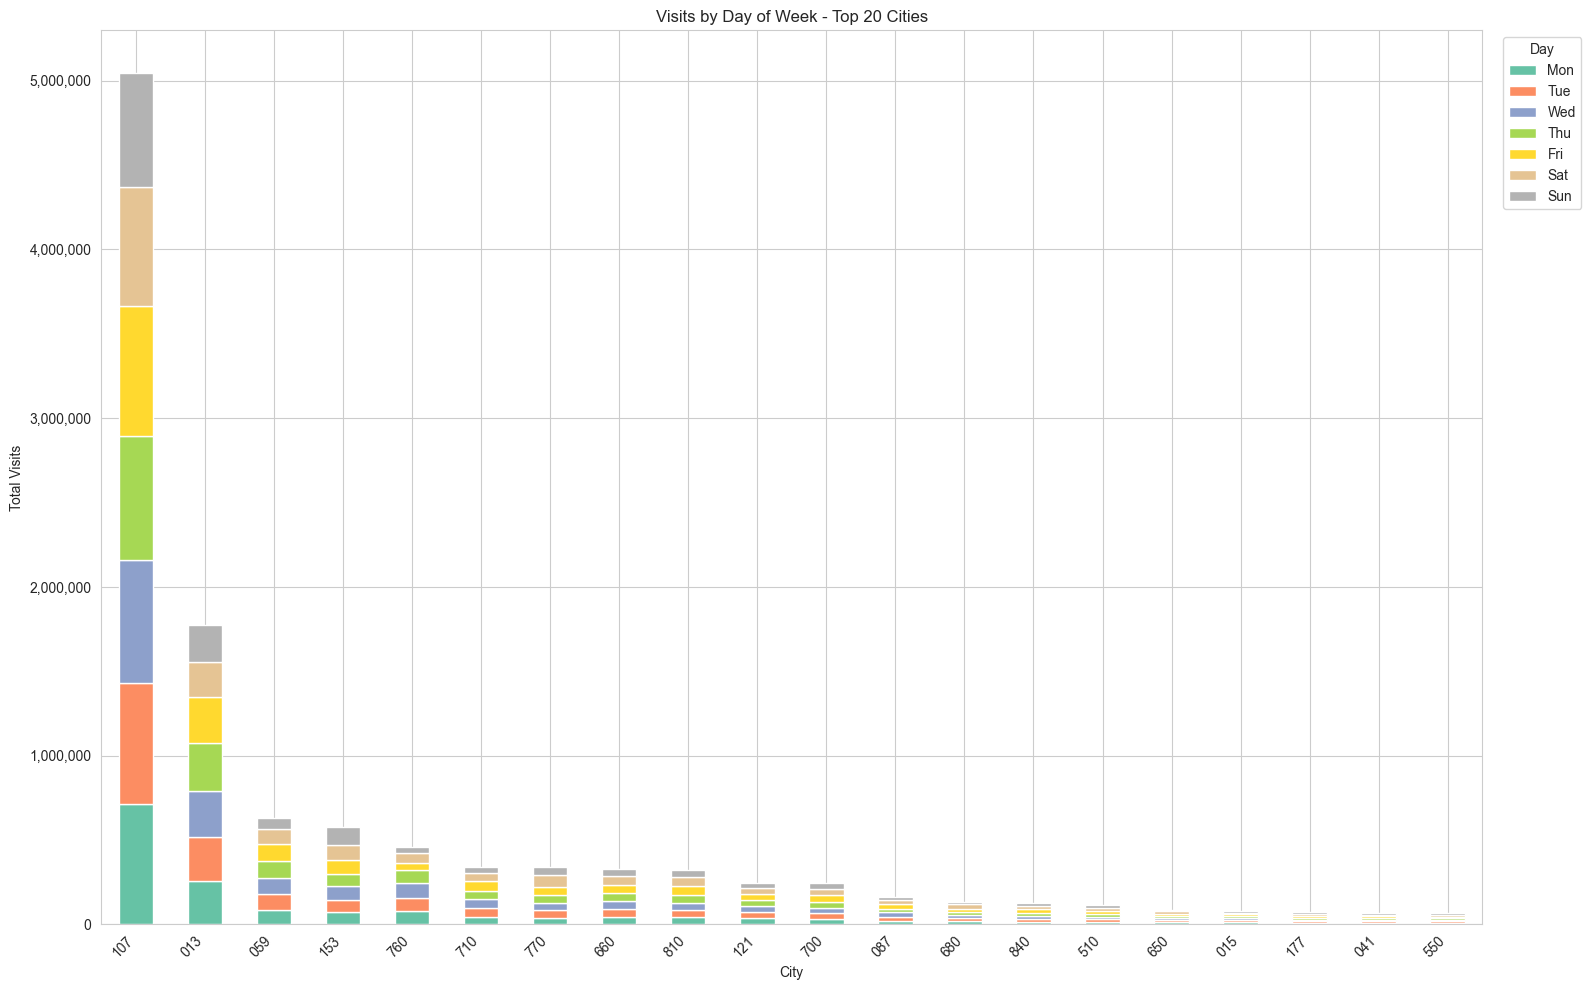

In [11]:
import json

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']


WeeklyPatterns_combined[days] = pd.DataFrame(
    WeeklyPatterns_combined['visits_by_day'].apply(
        lambda x: json.loads(x) if pd.notnull(x) else [0]*7
    ).tolist(), index=WeeklyPatterns_combined.index)

# Group by city and sum each day
plot_data = WeeklyPatterns_combined.groupby('county')[days].sum()

# Keep top 20 cities by total visits
top20 = plot_data.sum(axis=1).nlargest(20).index
plot_data_top = plot_data.loc[top20]

ax = plot_data_top.plot(kind='bar', stacked=True, figsize=(16, 10), colormap='Set2')
plt.title('Visits by Day of Week - Top 20 Cities')
plt.xlabel('City')
plt.ylabel('Total Visits')
plt.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [12]:
WeeklyPatterns_combined.to_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv', index=False)

KeyboardInterrupt: 

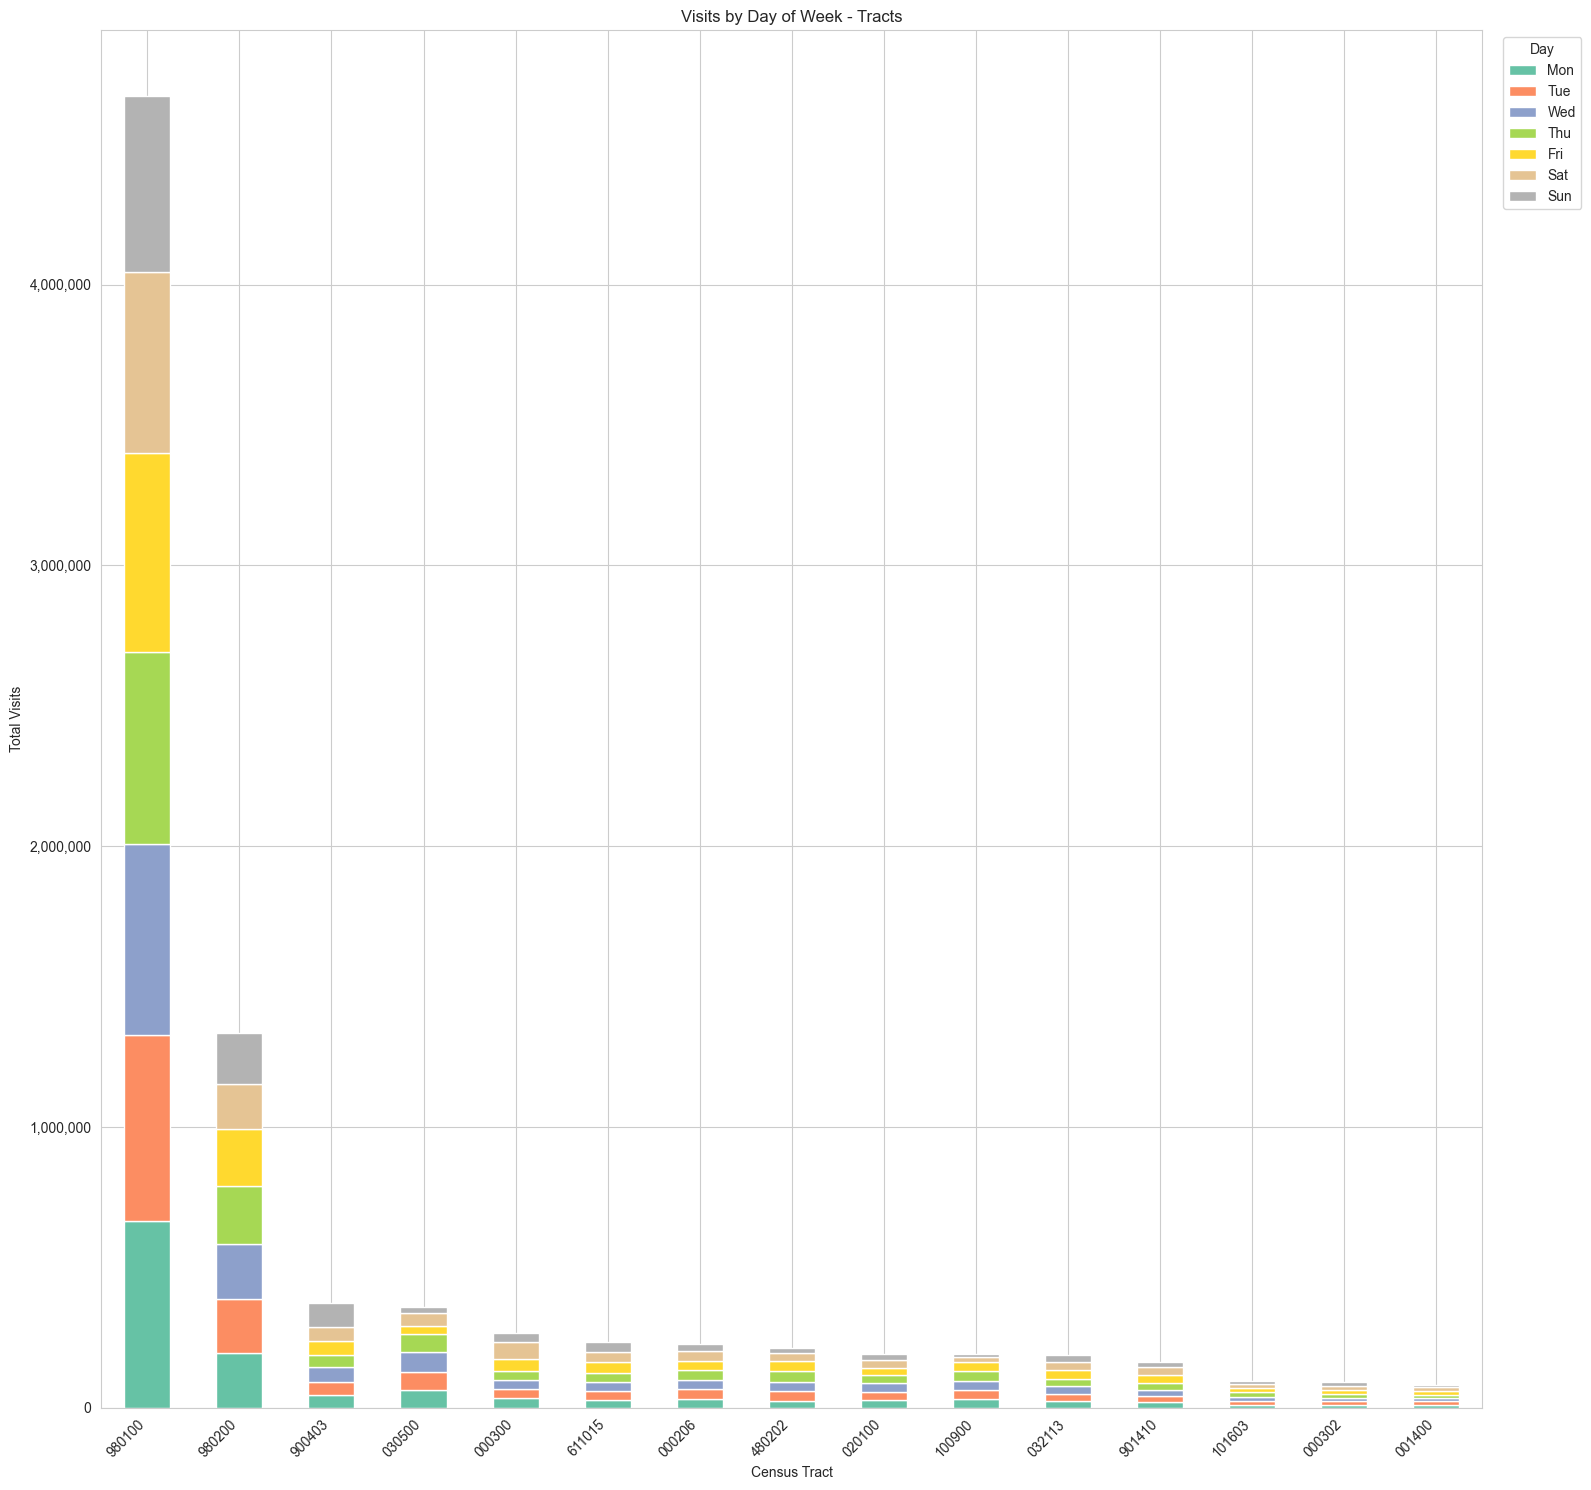

In [13]:
# Group by city and sum each day
plot_data2 = WeeklyPatterns_combined.groupby('census_tract')[days].sum()

# Keep top 20 cities by total visits
top15 = plot_data2.sum(axis=1).nlargest(15).index
plot_data_top = plot_data2.loc[top15]

ax = plot_data_top.plot(kind='bar', stacked=True, figsize=(16, 15), colormap='Set2')
plt.title('Visits by Day of Week - Tracts')
plt.xlabel('Census Tract')
plt.ylabel('Total Visits')
plt.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

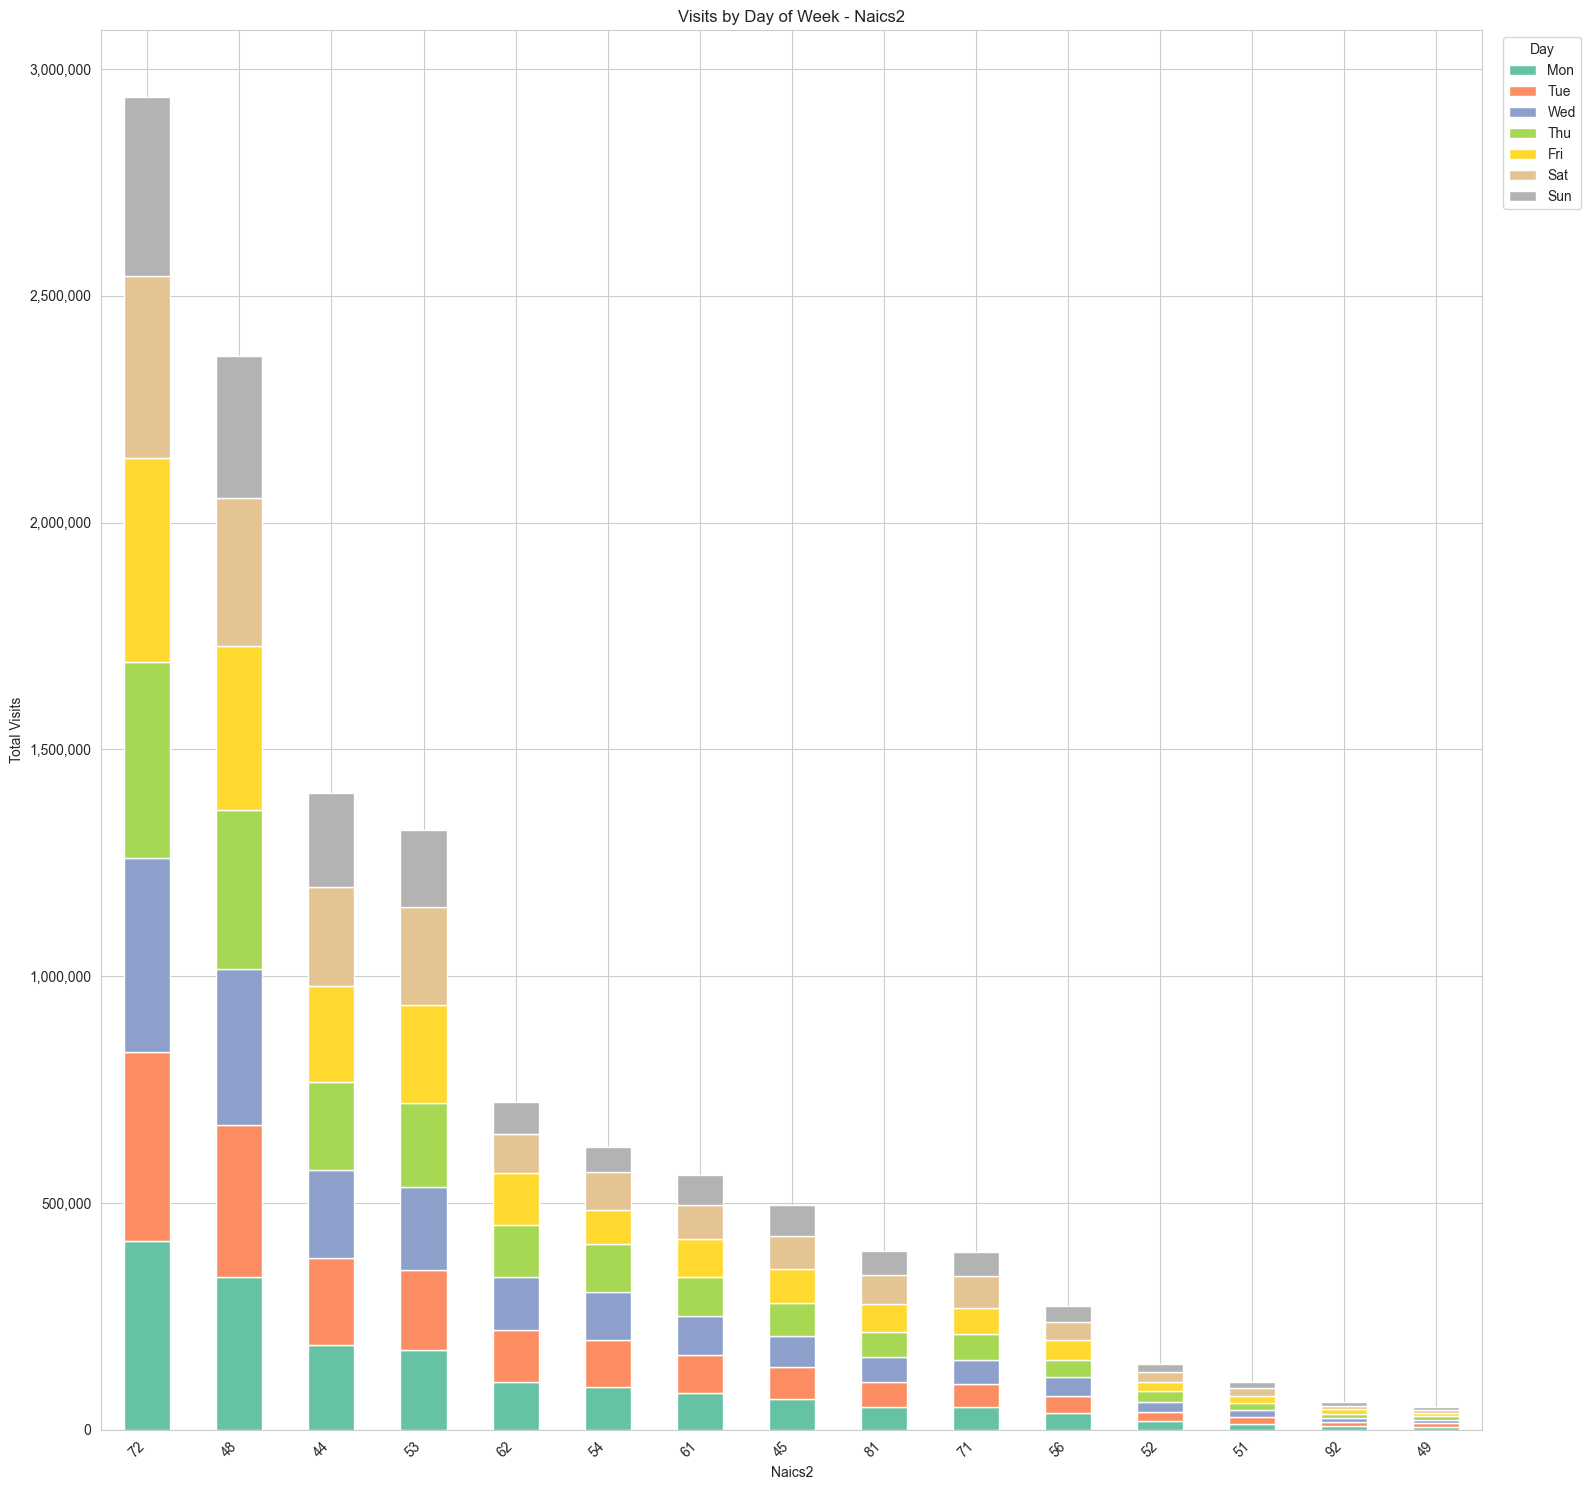

In [14]:
# Group by city and sum each day
plot_data3 = WeeklyPatterns_combined.groupby('naics2')[days].sum()

# Keep top 20 cities by total visits
top20 = plot_data3.sum(axis=1).nlargest(15).index
plot_data_top = plot_data3.loc[top20]

ax = plot_data_top.plot(kind='bar', stacked=True, figsize=(16, 15), colormap='Set2')
plt.title('Visits by Day of Week - Naics2')
plt.xlabel('Naics2')
plt.ylabel('Total Visits')
plt.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

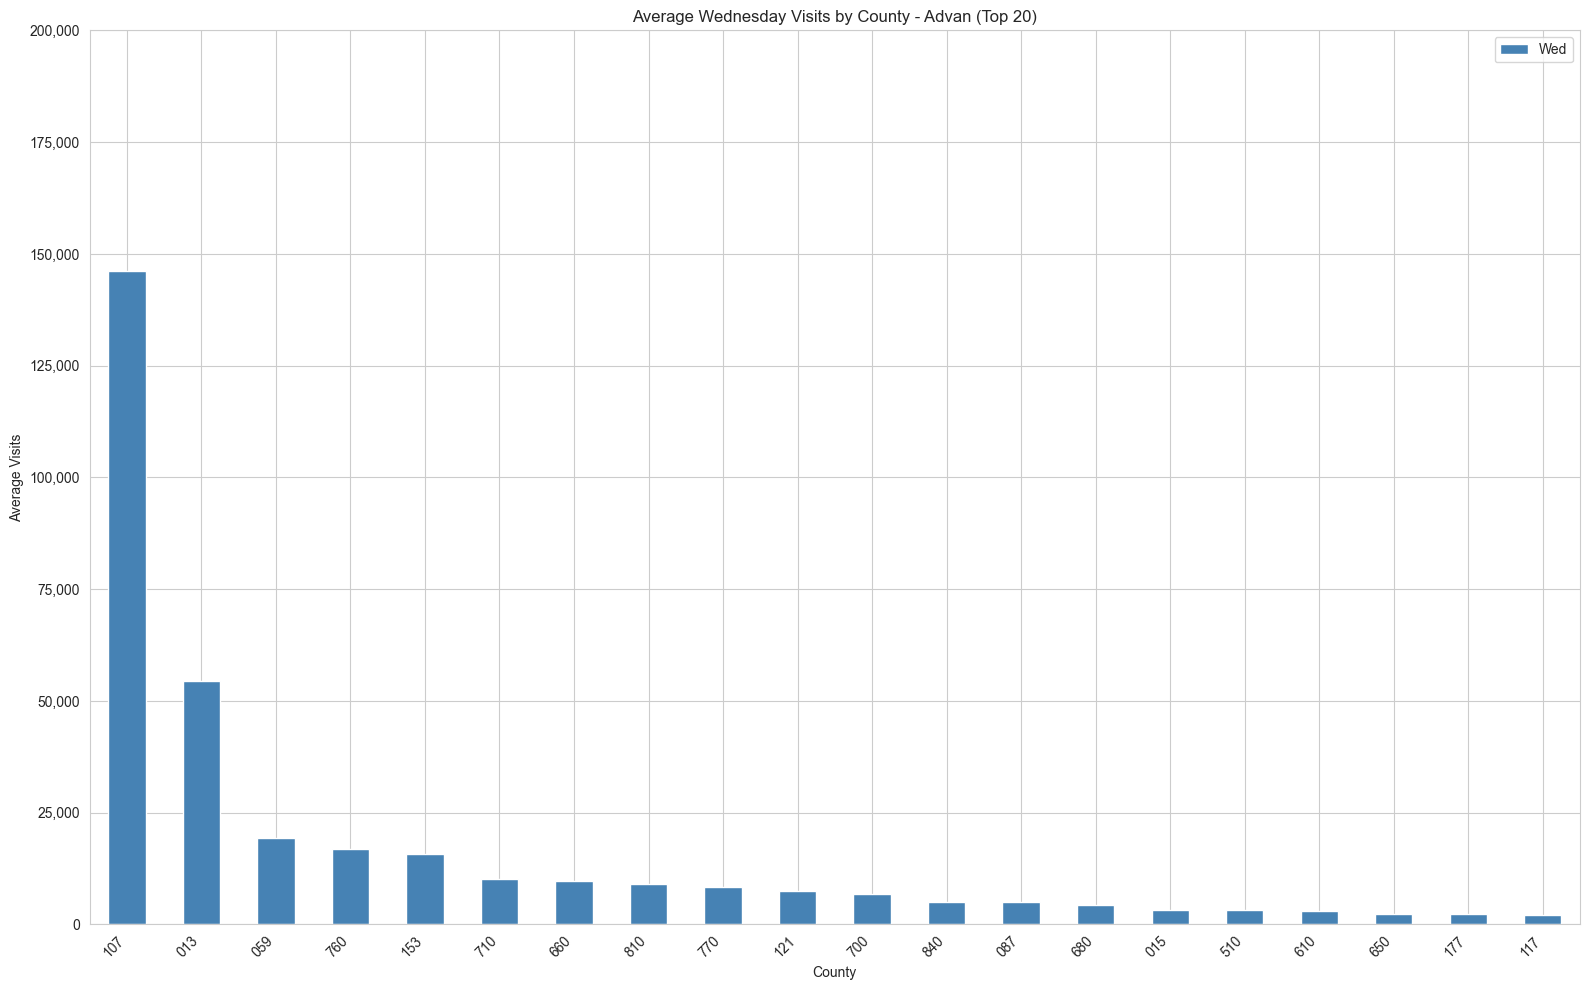

In [15]:
# Sum visits per county per week, then average across the 5 weeks
plot_data4 = (WeeklyPatterns_combined.groupby(['county', 'week_start'])[['Wed']]
              .sum()
              .groupby('county')
              .mean())

Ctop20 = plot_data4.nlargest(20, 'Wed').index
plot_data_top = plot_data4.loc[Ctop20]

ax = plot_data_top.plot(kind='bar', figsize=(16, 10), color='steelblue')
plt.title('Average Wednesday Visits by County - Advan (Top 20)')
plt.xlabel('County')
plt.ylabel('Average Visits')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.ylim(0, 200000)
plt.show()

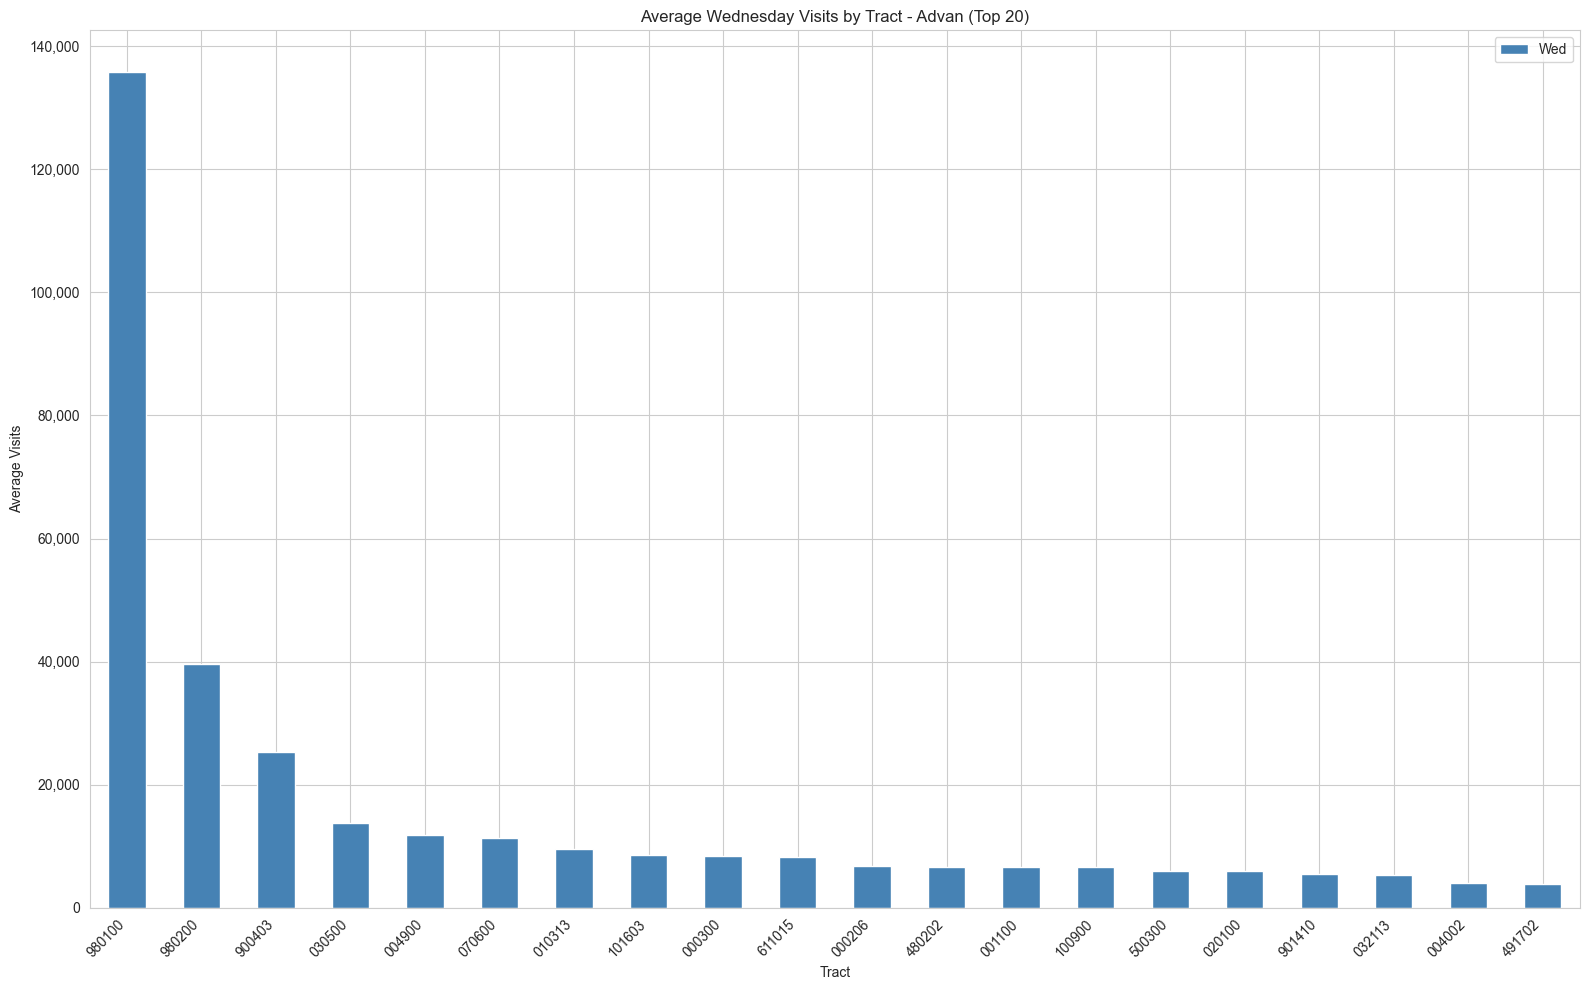

In [16]:

# Sum visits per county per week, then average across the 5 weeks
plot_data5 = (WeeklyPatterns_combined.groupby(['census_tract', 'week_start'])[['Wed']]
              .sum()
              .groupby('census_tract')
              .mean())

Ttop20 = plot_data5.nlargest(20, 'Wed').index
plot_data_top2 = plot_data5.loc[Ttop20]

ax = plot_data_top2.plot(kind='bar', figsize=(16, 10), color='steelblue')
plt.title('Average Wednesday Visits by Tract - Advan (Top 20)')
plt.xlabel('Tract')
plt.ylabel('Average Visits')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

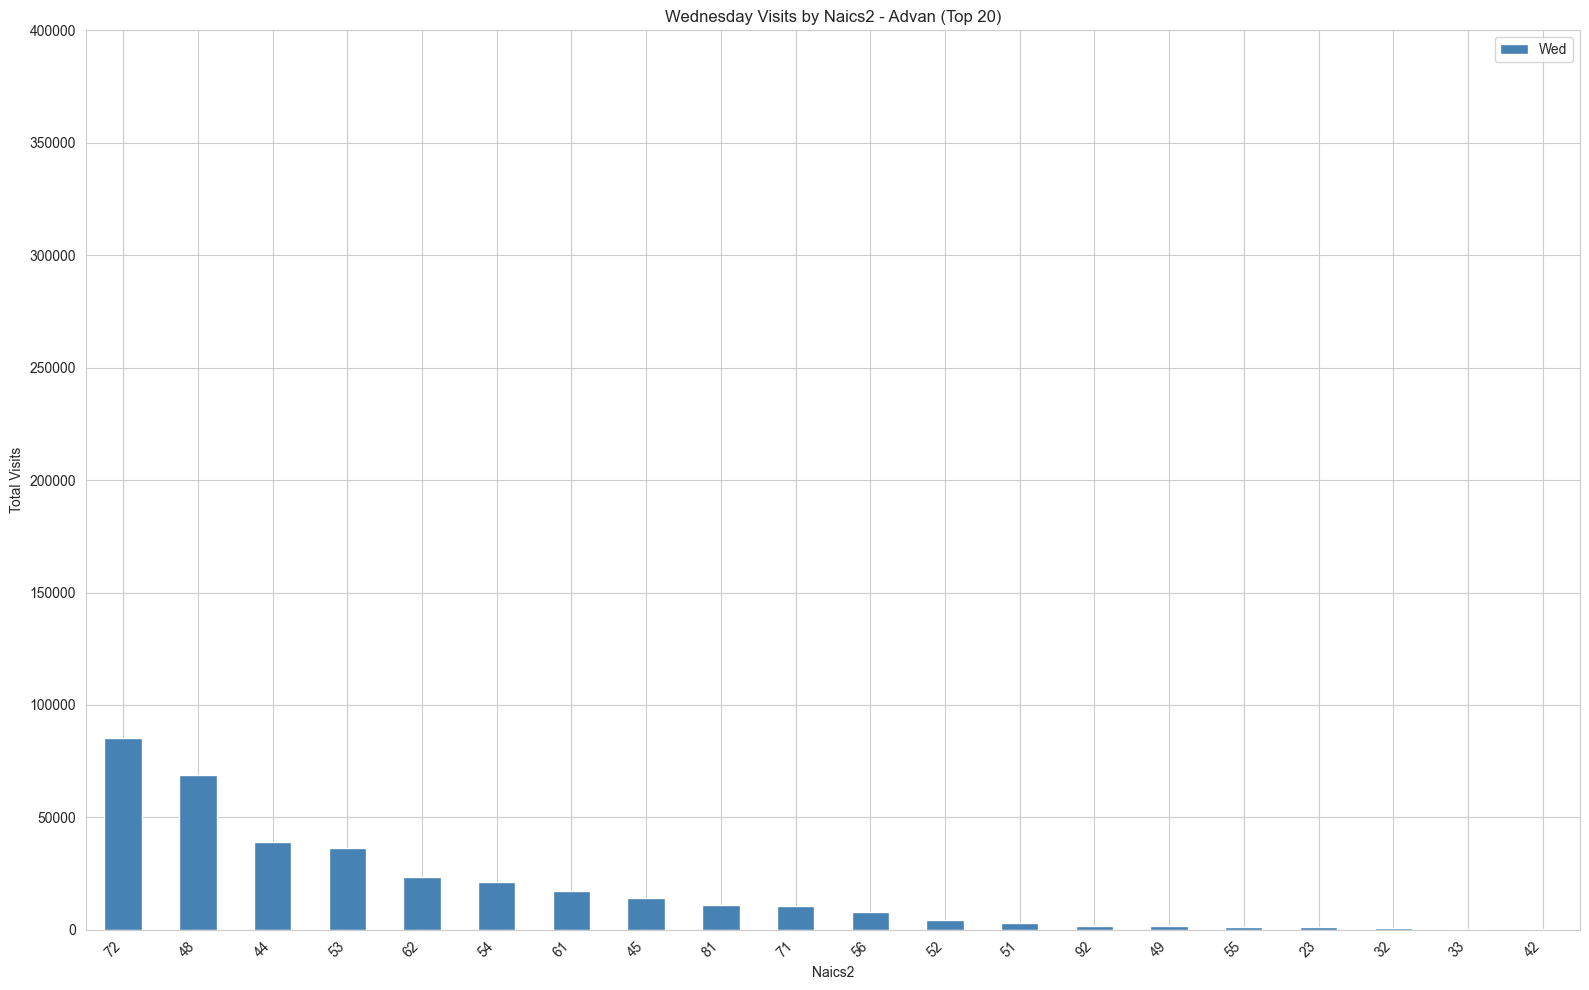

In [17]:
# Use just Wednesday from the already-parsed days columns
plot_data6 = (WeeklyPatterns_combined.groupby(['naics2', 'week_start'])[['Wed']]
              .sum()
              .groupby('naics2')
              .mean())

Ttop20 = plot_data6.nlargest(20, 'Wed').index
plot_data_top3 = plot_data6.loc[Ttop20]

ax3 = plot_data_top3.plot(kind='bar', figsize=(16, 10), color='steelblue')
plt.title('Wednesday Visits by Naics2 - Advan (Top 20)')
plt.xlabel('Naics2')
plt.ylabel('Total Visits')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 400000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [20]:
print(WeeklyPatterns_combined.shape)
print(WeeklyPatterns_combined['county'].nunique())

(8186, 63)
105


In [21]:
print(WeeklyPatterns_combined['Wed'].dtype)
print(WeeklyPatterns_combined['Wed'].value_counts())

int64
Wed
187     345
19      231
78      213
265     180
31      160
       ... 
360       1
6031      1
230       1
416       1
739       1
Name: count, Length: 528, dtype: int64
